# EE 446 TinyML — Model Pruning with Quantization  
## Student TODO Version: Pruning and Quantization of a DNN Using the UCI Human Activity Recognition Dataset

### Overview
In this notebook, you will:
- train a baseline DNN on the **UCI HAR** dataset,
- apply **magnitude-based pruning**,
- compare the pruned model before and after `strip_pruning(...)`, and
- combine pruning with **float16 quantization**.

Use the **`Python (tinyml-arduino)`** Jupyter kernel for this notebook.


## 1. Environment Setup

This notebook is designed to run with the **`Python (tinyml-arduino)`** Jupyter kernel that you already created.

This notebook assumes the environment already contains:
- `tensorflow==2.14.1`
- `tensorflow-model-optimization==0.8.0`
- `numpy`, `pandas`, `matplotlib`, and `scikit-learn`

Do **not** reinstall TensorFlow packages inside the notebook if you are already using the working TinyML environment.


In [15]:
import os
import math
import zipfile
import random
import urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import tensorflow_model_optimization as tfmot

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from tensorflow import keras
from tensorflow.keras import layers

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("Python executable:", os.sys.executable)
print("TensorFlow version:", tf.__version__)
print("TF-MOT version:", tfmot.__version__)


Python executable: /Users/raniaratulangis./ai/projects/tinyml-arduino/bin/python
TensorFlow version: 2.14.1
TF-MOT version: 0.8.0


## 2. Download and Extract the UCI HAR Dataset

The original dataset contains:
- **561 numerical features** extracted from smartphone sensor signals,
- **6 activity classes**, and
- predefined **training** and **test** splits.

The code below downloads and extracts the dataset if it is not already present in the working directory.


In [16]:
dataset_url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00240/UCI%20HAR%20Dataset.zip"
zip_path = "uci_har_dataset.zip"
extract_dir = "."

if not os.path.exists("UCI HAR Dataset"):
    urllib.request.urlretrieve(dataset_url, zip_path)
    with zipfile.ZipFile(zip_path, "r") as zf:
        zf.extractall(extract_dir)
    print("Dataset downloaded and extracted.")
else:
    print("Dataset directory already exists.")


Dataset directory already exists.


## 3. Load the Data

In [17]:
def load_har_data(root_dir="UCI HAR Dataset"):
    # TODO:
    # 1. Load X_train from train/X_train.txt as float32
    X_train = np.loadtxt(f"{root_dir}/train/X_train.txt", dtype=np.float32)
    # 2. Load y_train from train/y_train.txt as int32
    y_train = np.loadtxt(f"{root_dir}/train/y_train.txt", dtype=np.int32) - 1
    # 3. Load X_test from test/X_test.txt as float32
    X_test  = np.loadtxt(f"{root_dir}/test/X_test.txt",  dtype=np.float32)
    # 4. Load y_test from test/y_test.txt as int32
    y_test  = np.loadtxt(f"{root_dir}/test/y_test.txt",  dtype=np.int32) - 1
    # 5. Convert labels to zero-based class indices by subtracting 1
    return X_train, y_train, X_test, y_test

X_train, y_train, X_test, y_test = load_har_data()

class_names = [
    "WALKING",
    "WALKING_UPSTAIRS",
    "WALKING_DOWNSTAIRS",
    "SITTING",
    "STANDING",
    "LAYING"
]

# TODO:
# Define num_features and num_classes.
# Print the train/test shapes and the number of features/classes.

num_features = X_train.shape[1]
num_classes  = len(class_names)


## 4. Quick Inspection

In [18]:
# TODO:
# Create a small summary table showing:
# - class index,
# - class name, and
# - number of training samples in each class.

for i, name in enumerate(class_names):
    count = np.sum(y_train == i)
    print(f"{i} | {name:<20} | {count} samples")


0 | WALKING              | 1226 samples
1 | WALKING_UPSTAIRS     | 1073 samples
2 | WALKING_DOWNSTAIRS   | 986 samples
3 | SITTING              | 1286 samples
4 | STANDING             | 1374 samples
5 | LAYING               | 1407 samples


## 5. Train a Baseline DNN

We will use a compact dense neural network that is appropriate for a numerical-feature TinyML workflow.

### Architecture
- Input: 561 features
- Dense(256, ReLU)
- Dense(128, ReLU)
- Dense(64, ReLU)
- Dense(6, Softmax)


In [19]:
def build_baseline_model(input_dim, num_classes):
    # TODO:
    # Build and compile a DNN with the following architecture:
    # Input -> Dense(256, relu) -> Dense(128, relu) -> Dense(64, relu) -> Dense(num_classes, softmax)
    # Use Adam with learning rate 1e-3.
    # Use sparse_categorical_crossentropy as the loss.
    # Track accuracy as a metric.

    model = keras.Sequential([
        layers.Dense(256, activation="relu", input_shape=(input_dim,)),
        layers.Dense(128, activation="relu"),
        layers.Dense(64,  activation="relu"),
        layers.Dense(num_classes, activation="softmax")
    ])
    model.compile(
        optimizer=keras.optimizers.Adam(1e-3),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

baseline_model = build_baseline_model(num_features, num_classes)
baseline_model.summary()


Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_8 (Dense)             (None, 256)               143872    
                                                                 
 dense_9 (Dense)             (None, 128)               32896     
                                                                 
 dense_10 (Dense)            (None, 64)                8256      
                                                                 
 dense_11 (Dense)            (None, 6)                 390       
                                                                 
Total params: 185414 (724.27 KB)
Trainable params: 185414 (724.27 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


### Train the Baseline Model

In [20]:
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=5,
        restore_best_weights=True
    )
]

# TODO:
# Train the baseline model using:
# - validation_split=0.2
# - epochs=40
# - batch_size=64
# - callbacks=callbacks

history = baseline_model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=40,
    batch_size=64,
    callbacks=callbacks
)


Epoch 1/40
92/92 [==============================] - 0s 1ms/step - loss: 0.4880 - accuracy: 0.8075 - val_loss: 0.2016 - val_accuracy: 0.9245
Epoch 2/40
92/92 [==============================] - 0s 931us/step - loss: 0.1638 - accuracy: 0.9374 - val_loss: 0.1399 - val_accuracy: 0.9375
Epoch 3/40
92/92 [==============================] - 0s 949us/step - loss: 0.1152 - accuracy: 0.9568 - val_loss: 0.2632 - val_accuracy: 0.9123
Epoch 4/40
92/92 [==============================] - 0s 985us/step - loss: 0.0907 - accuracy: 0.9633 - val_loss: 0.1618 - val_accuracy: 0.9402
Epoch 5/40
92/92 [==============================] - 0s 946us/step - loss: 0.0905 - accuracy: 0.9646 - val_loss: 0.2719 - val_accuracy: 0.9205
Epoch 6/40
92/92 [==============================] - 0s 937us/step - loss: 0.0712 - accuracy: 0.9723 - val_loss: 0.2235 - val_accuracy: 0.9307
Epoch 7/40
92/92 [==============================] - 0s 962us/step - loss: 0.0588 - accuracy: 0.9776 - val_loss: 0.1442 - val_accuracy: 0.9422
Epoch 8/

### Training Curves

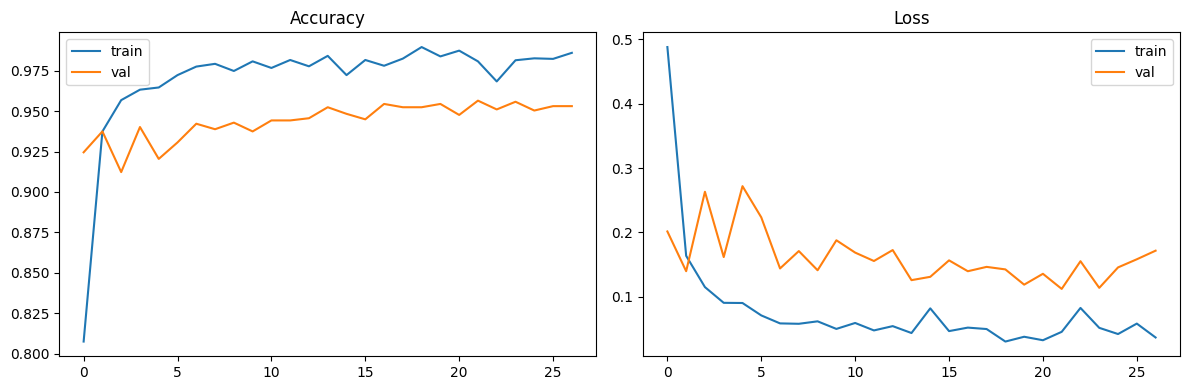

In [21]:
# TODO:
# Plot:
# 1. training accuracy vs validation accuracy
# 2. training loss vs validation loss

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history["accuracy"], label="train")
axes[0].plot(history.history["val_accuracy"], label="val")
axes[0].set_title("Accuracy"); axes[0].legend()

axes[1].plot(history.history["loss"], label="train")
axes[1].plot(history.history["val_loss"], label="val")
axes[1].set_title("Loss"); axes[1].legend()

plt.tight_layout()
plt.show()


## 6. Evaluate the Baseline Keras Model

93/93 [==============================] - 0s 378us/step
Baseline Test Accuracy: 0.9264
                    precision    recall  f1-score   support

           WALKING       0.86      1.00      0.92       496
  WALKING_UPSTAIRS       0.95      0.85      0.90       471
WALKING_DOWNSTAIRS       0.97      0.91      0.94       420
           SITTING       0.93      0.89      0.91       491
          STANDING       0.87      0.94      0.90       532
            LAYING       1.00      0.96      0.98       537

          accuracy                           0.93      2947
         macro avg       0.93      0.92      0.93      2947
      weighted avg       0.93      0.93      0.93      2947



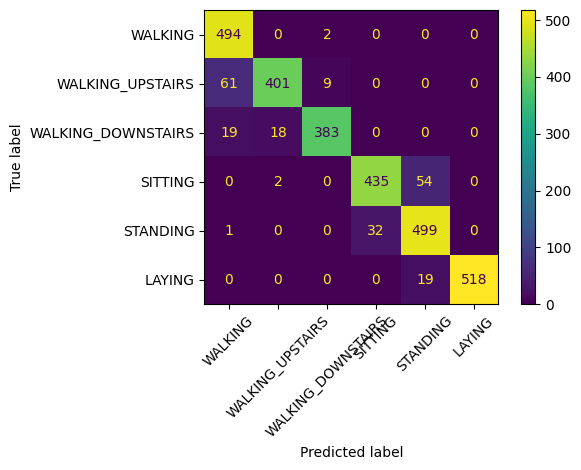

In [22]:
# TODO:
# 1. Predict class probabilities on X_test
# 2. Convert probabilities to class labels using argmax
# 3. Compute the test accuracy
# 4. Print the classification report
# 5. Plot the confusion matrix

y_probs = baseline_model.predict(X_test)
y_pred_base = np.argmax(y_probs, axis=1)
base_acc = accuracy_score(y_test, y_pred_base)
print(f"Baseline Test Accuracy: {base_acc:.4f}")
print(classification_report(y_test, y_pred_base, target_names=class_names))

cm = confusion_matrix(y_test, y_pred_base)
disp = ConfusionMatrixDisplay(cm, display_labels=class_names)
disp.plot(xticks_rotation=45) 
plt.tight_layout()
plt.show()


# Part I: Model Pruning with Sparsity

In this part, we apply **magnitude-based pruning** to the DNN. The key idea is to gradually set small-magnitude weights to zero during training.

We will compare:
1. the baseline TensorFlow Lite model,
2. the pruned model converted **without** stripping the pruning wrappers, and
3. the stripped sparse model converted with **experimental sparsity-aware optimization**.


## 7. TensorFlow Lite Utilities

The following helper functions are used to:
- convert Keras models to TensorFlow Lite,
- evaluate TensorFlow Lite models on the test set, and
- measure model size.


In [23]:
def save_binary_model(model_content, filename):
    with open(filename, "wb") as f:
        f.write(model_content)
    return os.path.getsize(filename) / 1024.0  # KB

def evaluate_tflite_model(tflite_model, X, y_true):
    interpreter = tf.lite.Interpreter(model_content=tflite_model)
    interpreter.allocate_tensors()

    input_details = interpreter.get_input_details()[0]
    output_details = interpreter.get_output_details()[0]

    input_scale, input_zero_point = input_details["quantization"]
    output_scale, output_zero_point = output_details["quantization"]

    y_pred = []

    for i in range(len(X)):
        x = X[i:i+1].astype(np.float32)

        # TODO:
        # Quantize the input only when the TFLite input tensor expects int8 or uint8.
        # Otherwise keep the input in the required floating-point dtype.

        if input_details["dtype"] in [np.int8, np.uint8]:
            x = (x / input_scale + input_zero_point).astype(input_details["dtype"])
        else:
            x = x.astype(input_details["dtype"])

        interpreter.set_tensor(input_details["index"], x)
        interpreter.invoke()

        output = interpreter.get_tensor(output_details["index"])

        # TODO:
        # Dequantize the output only when the output tensor is int8 or uint8.

        if output_details["dtype"] in [np.int8, np.uint8]:
            output = (output.astype(np.float32) - output_zero_point) * output_scale

        pred = int(np.argmax(output, axis=1)[0])
        y_pred.append(pred)

    acc = accuracy_score(y_true, y_pred)
    return acc, np.array(y_pred)

def convert_to_tflite_fp32(model):
    # TODO:
    # Create a TFLiteConverter from the Keras model and return the converted FP32 model bytes.

    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    return converter.convert()


## 8. Convert the Baseline Model to TensorFlow Lite

In [24]:
# TODO:
# Convert the baseline model to FP32 TensorFlow Lite.
# Save the .tflite file, compute its size in KB, and evaluate it on X_test.

baseline_tflite = convert_to_tflite_fp32(baseline_model)
baseline_size_kb = save_binary_model(baseline_tflite, "baseline_fp32.tflite")
baseline_tflite_acc, _ = evaluate_tflite_model(baseline_tflite, X_test, y_test)


INFO:tensorflow:Assets written to: /var/folders/2y/vkd4h1tj22j6xmw68ffqhg1c0000gn/T/tmp0goy0zzy/assets


INFO:tensorflow:Assets written to: /var/folders/2y/vkd4h1tj22j6xmw68ffqhg1c0000gn/T/tmp0goy0zzy/assets
2026-04-25 17:03:12.761882: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-04-25 17:03:12.761894: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-04-25 17:03:12.761959: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /var/folders/2y/vkd4h1tj22j6xmw68ffqhg1c0000gn/T/tmp0goy0zzy
2026-04-25 17:03:12.762311: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-04-25 17:03:12.762320: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /var/folders/2y/vkd4h1tj22j6xmw68ffqhg1c0000gn/T/tmp0goy0zzy
2026-04-25 17:03:12.763260: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-04-25 17:03:12.779380: I tensorflow/cc/saved_model/loader.cc:217] Running initialization

## 9. Apply Magnitude-Based Pruning

We will prune the DNN using a **polynomial decay schedule**:
- start from low sparsity,
- gradually increase sparsity during training, and
- finish with a highly sparse model.

After training, we will compare:
- the pruned model **with** the pruning wrappers still present, and
- the final sparse model after applying `strip_pruning(...)`.


In [25]:
from tensorflow_model_optimization.sparsity.keras import (
    prune_low_magnitude,
    PolynomialDecay,
    UpdatePruningStep,
    strip_pruning
)

pruning_epochs = 12
batch_size = 64

# TODO:
# Compute steps_per_epoch using 80% of the training set and the selected batch size.
# Define pruning_params using PolynomialDecay with:
# - initial_sparsity=0.20
# - final_sparsity=0.85
# - begin_step=0
# - end_step=steps_per_epoch * pruning_epochs

steps_per_epoch = math.ceil(len(X_train) * 0.8 / batch_size)

pruning_params = {
    "pruning_schedule": PolynomialDecay(
        initial_sparsity=0.20,
        final_sparsity=0.85,
        begin_step=0,
        end_step=steps_per_epoch * pruning_epochs
    )
}

# TODO:
# Create the pruned model by wrapping a fresh baseline DNN with prune_low_magnitude.
# Compile it with Adam(1e-3), sparse_categorical_crossentropy, and accuracy.

pruned_model = prune_low_magnitude(
    build_baseline_model(num_features, num_classes),
    **pruning_params
)
pruned_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

pruning_callbacks = [
    UpdatePruningStep(),
    keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=3,
        restore_best_weights=True
    )
]

# TODO:
# Train the pruned model using:
# - validation_split=0.2
# - epochs=pruning_epochs
# - batch_size=batch_size
# - callbacks=pruning_callbacks

pruned_model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=pruning_epochs,
    batch_size=batch_size,
    callbacks=pruning_callbacks
)


Epoch 1/12
92/92 [==============================] - 1s 2ms/step - loss: 0.4751 - accuracy: 0.8067 - val_loss: 0.2226 - val_accuracy: 0.9218
Epoch 2/12
92/92 [==============================] - 0s 1ms/step - loss: 0.1662 - accuracy: 0.9367 - val_loss: 0.1591 - val_accuracy: 0.9293
Epoch 3/12
92/92 [==============================] - 0s 1ms/step - loss: 0.1314 - accuracy: 0.9493 - val_loss: 0.2293 - val_accuracy: 0.9252
Epoch 4/12
92/92 [==============================] - 0s 1ms/step - loss: 0.0901 - accuracy: 0.9699 - val_loss: 0.1750 - val_accuracy: 0.9334
Epoch 5/12
92/92 [==============================] - 0s 1ms/step - loss: 0.1388 - accuracy: 0.9476 - val_loss: 0.1383 - val_accuracy: 0.9415
Epoch 6/12
92/92 [==============================] - 0s 1ms/step - loss: 0.1209 - accuracy: 0.9607 - val_loss: 0.1783 - val_accuracy: 0.9347
Epoch 7/12
92/92 [==============================] - 0s 1ms/step - loss: 0.3121 - accuracy: 0.9255 - val_loss: 0.1751 - val_accuracy: 0.9334
Epoch 8/12
92/92 [==

## 10. Convert the Pruned Model Before and After Stripping the Pruning Wrappers

First, we convert the pruned model **with** the pruning wrappers still attached.

Next, we strip the pruning wrappers and convert the resulting sparse model with:
- `tf.lite.Optimize.EXPERIMENTAL_SPARSITY`

This is the proper way to preserve sparsity in the exported TensorFlow Lite model.


In [28]:
# TODO:
# 1. Convert the pruned model WITH the pruning wrappers still attached to FP32 TensorFlow Lite.
# 2. Save the model and evaluate it on X_test.
# 3. Strip the pruning wrappers using strip_pruning(...).
# 4. Convert the stripped model with tf.lite.Optimize.EXPERIMENTAL_SPARSITY.
# 5. Save the stripped sparse model and evaluate it on X_test.

pruned_with_mask_tflite = convert_to_tflite_fp32(pruned_model)
pruned_mask_size_kb = save_binary_model(pruned_with_mask_tflite, "pruned_with_mask_fp32.tflite")
pruned_mask_acc, _ = evaluate_tflite_model(pruned_with_mask_tflite, X_test, y_test)

stripped_model = strip_pruning(pruned_model)
converter = tf.lite.TFLiteConverter.from_keras_model(stripped_model)
converter.optimizations = [tf.lite.Optimize.EXPERIMENTAL_SPARSITY]
stripped_tflite = converter.convert()
stripped_size_kb = save_binary_model(stripped_tflite, "stripped_sparse_fp32.tflite")
stripped_acc, stripped_preds = evaluate_tflite_model(stripped_tflite, X_test, y_test)

INFO:tensorflow:Assets written to: /var/folders/2y/vkd4h1tj22j6xmw68ffqhg1c0000gn/T/tmpx11_g2wi/assets


INFO:tensorflow:Assets written to: /var/folders/2y/vkd4h1tj22j6xmw68ffqhg1c0000gn/T/tmpx11_g2wi/assets
2026-04-25 17:05:06.895205: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-04-25 17:05:06.895242: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-04-25 17:05:06.895355: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /var/folders/2y/vkd4h1tj22j6xmw68ffqhg1c0000gn/T/tmpx11_g2wi
2026-04-25 17:05:06.896664: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-04-25 17:05:06.896670: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /var/folders/2y/vkd4h1tj22j6xmw68ffqhg1c0000gn/T/tmpx11_g2wi
2026-04-25 17:05:06.900517: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-04-25 17:05:06.922047: I tensorflow/cc/saved_model/loader.cc:217] Running initialization

INFO:tensorflow:Assets written to: /var/folders/2y/vkd4h1tj22j6xmw68ffqhg1c0000gn/T/tmpthci38ru/assets


INFO:tensorflow:Assets written to: /var/folders/2y/vkd4h1tj22j6xmw68ffqhg1c0000gn/T/tmpthci38ru/assets
2026-04-25 17:05:07.329313: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-04-25 17:05:07.329322: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-04-25 17:05:07.329399: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /var/folders/2y/vkd4h1tj22j6xmw68ffqhg1c0000gn/T/tmpthci38ru
2026-04-25 17:05:07.329630: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-04-25 17:05:07.329633: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /var/folders/2y/vkd4h1tj22j6xmw68ffqhg1c0000gn/T/tmpthci38ru
2026-04-25 17:05:07.330185: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-04-25 17:05:07.337206: I tensorflow/cc/saved_model/loader.cc:217] Running initialization

## 11. Part I Comparison: Accuracy and Model Size

In [29]:
# TODO:
# Create a comparison DataFrame for Part I with the columns:
# Model, Format, Test Accuracy, Model Size (KB)

# Include:
# - baseline FP32 TFLite
# - pruned FP32 TFLite with mask
# - stripped sparse FP32 TFLite

part1_df = pd.DataFrame([
    {"Model": "Baseline", "Format": "FP32", "Test Accuracy": baseline_tflite_acc, "Model Size (KB)": baseline_size_kb},
    {"Model": "Pruned (with mask)", "Format": "FP32", "Test Accuracy": pruned_mask_acc, "Model Size (KB)": pruned_mask_size_kb},
    {"Model": "Stripped Sparse", "Format": "FP32 + Sparsity",  "Test Accuracy": stripped_acc, "Model Size (KB)": stripped_size_kb},
])
print(part1_df.to_string(index=False))


             Model          Format  Test Accuracy  Model Size (KB)
          Baseline            FP32       0.926366       726.785156
Pruned (with mask)            FP32       0.937564      1454.269531
   Stripped Sparse FP32 + Sparsity       0.937564       163.062500


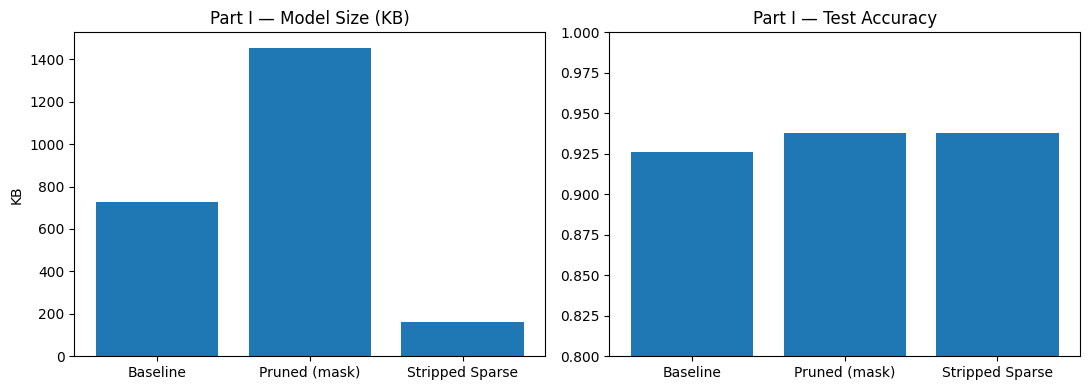

In [31]:
# TODO:
# Plot:
# 1. a bar chart of the Part I model sizes
# 2. a bar chart of the Part I test accuracies

labels = ["Baseline", "Pruned (mask)", "Stripped Sparse"]
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].bar(labels, [baseline_size_kb, pruned_mask_size_kb, stripped_size_kb])
axes[0].set_title("Part I — Model Size (KB)"); axes[0].set_ylabel("KB")
axes[1].bar(labels, [baseline_tflite_acc, pruned_mask_acc, stripped_acc])
axes[1].set_title("Part I — Test Accuracy"); axes[1].set_ylim(0.8, 1)
plt.tight_layout() 
plt.show()


### Confusion Matrix for the Stripped Sparse Model

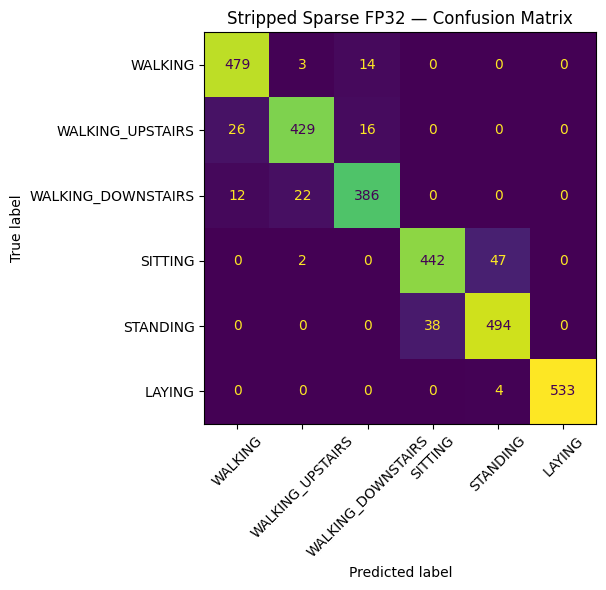

                    precision    recall  f1-score   support

           WALKING       0.93      0.97      0.95       496
  WALKING_UPSTAIRS       0.94      0.91      0.93       471
WALKING_DOWNSTAIRS       0.93      0.92      0.92       420
           SITTING       0.92      0.90      0.91       491
          STANDING       0.91      0.93      0.92       532
            LAYING       1.00      0.99      1.00       537

          accuracy                           0.94      2947
         macro avg       0.94      0.94      0.94      2947
      weighted avg       0.94      0.94      0.94      2947



In [32]:
# TODO:
# Plot the confusion matrix for the stripped sparse TFLite model.
# Print the classification report for the stripped sparse TFLite model.

cm = confusion_matrix(y_test, stripped_preds)
disp = ConfusionMatrixDisplay(cm, display_labels=class_names)
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, xticks_rotation=45, colorbar=False)
plt.title("Stripped Sparse FP32 — Confusion Matrix")
plt.tight_layout()
plt.show()
print(classification_report(y_test, stripped_preds, target_names=class_names))


# Part II: Model Pruning + Float16 Quantization

In this part, we combine **pruning** and **float16 quantization**.

We will compare:
1. the pruned TensorFlow Lite model **with** the pruning wrappers still attached, after float16 quantization, and
2. the stripped sparse TensorFlow Lite model after **both** sparsity-aware optimization and float16 quantization.

This lets us observe whether properly finalizing the pruned model leads to a more compact deployable representation.


In [33]:
# TODO:
# Part II: combine pruning and float16 quantization.
#
# 1. Convert the pruned model with mask using:
#    - optimizations = [tf.lite.Optimize.DEFAULT]
#    - supported_types = [tf.float16]
# 2. Save and evaluate the float16 model with mask.
# 3. Convert the stripped sparse model using:
#    - optimizations = [tf.lite.Optimize.DEFAULT, tf.lite.Optimize.EXPERIMENTAL_SPARSITY]
#    - supported_types = [tf.float16]
# 4. Save and evaluate the stripped sparse + float16 model.

conv = tf.lite.TFLiteConverter.from_keras_model(pruned_model)
conv.optimizations = [tf.lite.Optimize.DEFAULT]
conv.target_spec.supported_types = [tf.float16]
pruned_mask_f16_tflite  = conv.convert()
pruned_mask_f16_size_kb = save_binary_model(pruned_mask_f16_tflite, "pruned_with_mask_f16.tflite")
pruned_mask_f16_acc, _  = evaluate_tflite_model(pruned_mask_f16_tflite, X_test, y_test)

conv2 = tf.lite.TFLiteConverter.from_keras_model(stripped_model)
conv2.optimizations = [tf.lite.Optimize.DEFAULT, tf.lite.Optimize.EXPERIMENTAL_SPARSITY]
conv2.target_spec.supported_types = [tf.float16]
stripped_f16_tflite = conv2.convert()
stripped_f16_size_kb = save_binary_model(stripped_f16_tflite, "stripped_sparse_f16.tflite")
stripped_f16_acc, stripped_f16_preds = evaluate_tflite_model(stripped_f16_tflite, X_test, y_test)


INFO:tensorflow:Assets written to: /var/folders/2y/vkd4h1tj22j6xmw68ffqhg1c0000gn/T/tmpi9gl5u1u/assets


INFO:tensorflow:Assets written to: /var/folders/2y/vkd4h1tj22j6xmw68ffqhg1c0000gn/T/tmpi9gl5u1u/assets
2026-04-25 17:06:59.246156: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-04-25 17:06:59.246168: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-04-25 17:06:59.246261: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /var/folders/2y/vkd4h1tj22j6xmw68ffqhg1c0000gn/T/tmpi9gl5u1u
2026-04-25 17:06:59.247971: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-04-25 17:06:59.247976: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /var/folders/2y/vkd4h1tj22j6xmw68ffqhg1c0000gn/T/tmpi9gl5u1u
2026-04-25 17:06:59.253694: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-04-25 17:06:59.281670: I tensorflow/cc/saved_model/loader.cc:217] Running initialization

INFO:tensorflow:Assets written to: /var/folders/2y/vkd4h1tj22j6xmw68ffqhg1c0000gn/T/tmpf3s8hxrh/assets


INFO:tensorflow:Assets written to: /var/folders/2y/vkd4h1tj22j6xmw68ffqhg1c0000gn/T/tmpf3s8hxrh/assets
2026-04-25 17:06:59.908626: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-04-25 17:06:59.908635: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-04-25 17:06:59.908699: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /var/folders/2y/vkd4h1tj22j6xmw68ffqhg1c0000gn/T/tmpf3s8hxrh
2026-04-25 17:06:59.908925: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-04-25 17:06:59.908928: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /var/folders/2y/vkd4h1tj22j6xmw68ffqhg1c0000gn/T/tmpf3s8hxrh
2026-04-25 17:06:59.909482: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-04-25 17:06:59.916542: I tensorflow/cc/saved_model/loader.cc:217] Running initialization

## 12. Part II Comparison: Accuracy and Model Size

In [34]:
# TODO:
# Create a Part II comparison DataFrame with the columns:
# Model, Format, Test Accuracy, Model Size (KB)
#
# Include:
# - pruned FP32 with mask
# - stripped sparse FP32
# - pruned float16 with mask
# - stripped sparse float16

part2_df = pd.DataFrame([
    {"Model": "Pruned (mask)", "Format": "FP32", "Test Accuracy": pruned_mask_acc, "Model Size (KB)": pruned_mask_size_kb},
    {"Model": "Stripped Sparse", "Format": "FP32", "Test Accuracy": stripped_acc, "Model Size (KB)": stripped_size_kb},
    {"Model": "Pruned (mask)", "Format": "Float16", "Test Accuracy": pruned_mask_f16_acc, "Model Size (KB)": pruned_mask_f16_size_kb},
    {"Model": "Stripped Sparse", "Format": "Float16", "Test Accuracy": stripped_f16_acc, "Model Size (KB)": stripped_f16_size_kb},
])
print(part2_df.to_string(index=False))


          Model  Format  Test Accuracy  Model Size (KB)
  Pruned (mask)    FP32       0.937564      1454.269531
Stripped Sparse    FP32       0.937564       163.062500
  Pruned (mask) Float16       0.937564       732.679688
Stripped Sparse Float16       0.937564       108.789062


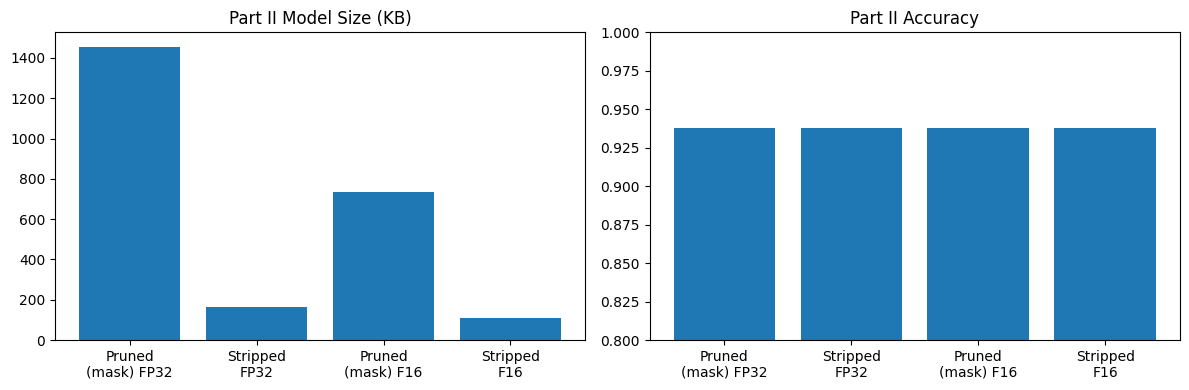

In [36]:
# TODO:
# Plot:
# 1. a bar chart of Part II model sizes
# 2. a bar chart of Part II test accuracies

labels2 = ["Pruned\n(mask) FP32", "Stripped\nFP32", "Pruned\n(mask) F16", "Stripped\nF16"]
sizes2  = [pruned_mask_size_kb, stripped_size_kb, pruned_mask_f16_size_kb, stripped_f16_size_kb]
accs2   = [pruned_mask_acc, stripped_acc, pruned_mask_f16_acc, stripped_f16_acc]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(labels2, sizes2); axes[0].set_title("Part II Model Size (KB)")
axes[1].bar(labels2, accs2); axes[1].set_title("Part II Accuracy"); axes[1].set_ylim(0.8, 1)
plt.tight_layout()
plt.show()


### Confusion Matrix for the Stripped Sparse + Float16 Model

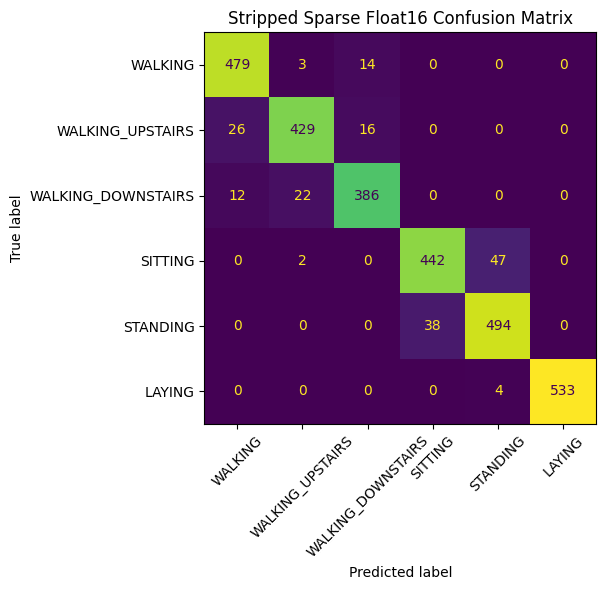

                    precision    recall  f1-score   support

           WALKING       0.93      0.97      0.95       496
  WALKING_UPSTAIRS       0.94      0.91      0.93       471
WALKING_DOWNSTAIRS       0.93      0.92      0.92       420
           SITTING       0.92      0.90      0.91       491
          STANDING       0.91      0.93      0.92       532
            LAYING       1.00      0.99      1.00       537

          accuracy                           0.94      2947
         macro avg       0.94      0.94      0.94      2947
      weighted avg       0.94      0.94      0.94      2947



In [38]:
# TODO:
# Plot the confusion matrix for the stripped sparse + float16 TFLite model.
# Print the classification report for the stripped sparse + float16 TFLite model.

cm = confusion_matrix(y_test, stripped_f16_preds)
disp = ConfusionMatrixDisplay(cm, display_labels=class_names)
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, xticks_rotation=45, colorbar=False)
plt.title("Stripped Sparse Float16 Confusion Matrix")
plt.tight_layout()
plt.show()
print(classification_report(y_test, stripped_f16_preds, target_names=class_names))


## 13. Summary Questions

Write short answers to the following:
1. Did pruning alone reduce the TensorFlow Lite file size when the pruning wrappers were still attached?
No, the pruned model with wrappers was actually larger than the baseline. This is because the pruning wrappers add extra overhead to the model during training that inflates the file size.
2. Why does `strip_pruning(...)` matter before export?
The pruning wrappers are only needed during training, so keeping them in the exported model wastes space. Stripping them lets the converter actually take advantage of the zero weights and compress them properly.
3. Which model had the smallest file size in this notebook?
The stripped sparse Float16 model at 108.79 KB. The combination of stripping, sparsity-aware optimization, and float16 quantization together gave the best compression overall.
4. Did float16 quantization noticeably change the test accuracy?
No, the accuracy stayed at 93.76% across all the pruned models regardless of whether float16 was applied. float16 gave a smaller model for free with no tradeoff for accuracy.
5. If you were deploying this model on a resource-constrained device, which version would you choose and why?
I'd use the stripped sparse Float16 model. It's the smallest at 108.79 KB and still hits 93.76% accuracy, which matches all the other pruned versions. Since it uses pruning, sparsity-aware export, and float16 quantization together without losing any accuracy, it is suitable for deployment on a resource-constrained device.


## 14. Submission Requirements

Submit the following:
- your completed notebook,
- the generated `.tflite` files,
- output cells or screenshots showing the comparison tables,
- confusion matrices for the baseline model and your final highlighted compressed model,
- and short written observations answering the summary questions.

Make sure your notebook runs from top to bottom without errors using the **`Python (tinyml-arduino)`** kernel.
